# Extra Trees — Network Intrusion Detection

Huấn luyện và đánh giá mô hình **Extra Trees (Extremely Randomized Trees)** trên tập dữ liệu CICIDS2017.
Extra Trees tương tự Random Forest nhưng chọn ngưỡng split ngẫu nhiên thay vì tìm ngưỡng tối ưu, giúp giảm variance và tăng tốc training.

In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesClassifier

# Thêm thư mục gốc dự án vào sys.path
sys.path.insert(0, str(Path.cwd()))
sys.path.append(os.path.abspath(".."))

from src.model_training import (
    load_splits,
    evaluate_model,
    plot_confusion_matrix,
    compare_models,
)

In [2]:
# --- STEP 1: Load dữ liệu đã chia sẵn ---
print("=" * 70)
print("STEP 1: Loading pre-split data")
print("=" * 70)

X_train, X_test, y_train, y_test = load_splits()

print(f"Feature columns: {X_train.shape[1]}")
print(f"Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading pre-split data
Loaded splits from disk.
Feature columns: 52
Train size: 2,016,609  |  Test size: 504,153
Classes: ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Heartbleed', 'PortScan', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [3]:
# --- STEP 2: Train Extra Trees ---
print("\n" + "=" * 70)
print("STEP 2: Training Extra Trees (n_estimators=300)")
print("=" * 70)

t0 = time.time()

et_model = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("\nTraining model...")
et_model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"\nTraining completed in {train_time:.2f} seconds")


STEP 2: Training Extra Trees (n_estimators=300)

Training model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   31.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  2.9min



Training completed in 280.66 seconds


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  4.3min finished


In [4]:
# --- STEP 3: Evaluate ---
print("\n" + "=" * 70)
print("STEP 3: Model Evaluation")
print("=" * 70)

y_pred = et_model.predict(X_test)
y_pred_proba = et_model.predict_proba(X_test)

et_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name="Extra Trees (n_estimators=300)",
    y_pred_proba=y_pred_proba,
    labels=et_model.classes_.tolist(),
)


STEP 3: Model Evaluation


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    3.9s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    6.8s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.8s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    4.9s
[Parallel(n_jobs=10)]: Done 300 out of 300 | elapsed:    8.2s finished



  Extra Trees (n_estimators=300) — Evaluation Results
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.85      0.75      0.80       390
               Brute Force       1.00      0.99      1.00      1830
                      DDoS       1.00      1.00      1.00     25603
                       DoS       1.00      1.00      1.00     38749
                Heartbleed       1.00      1.00      1.00         2
                  PortScan       0.99      0.99      0.99     18139
  Web Attack � Brute Force       0.71      0.77      0.74       294
Web Attack � Sql Injection       0.50      0.25      0.33         4
          Web Attack � XSS       0.33      0.25      0.29       130

                  accuracy                           1.00    504153
                 macro avg       0.84      0.80      0.81    504153
              weighted avg       1.00      1.00      1.00  


STEP 4: Confusion Matrix


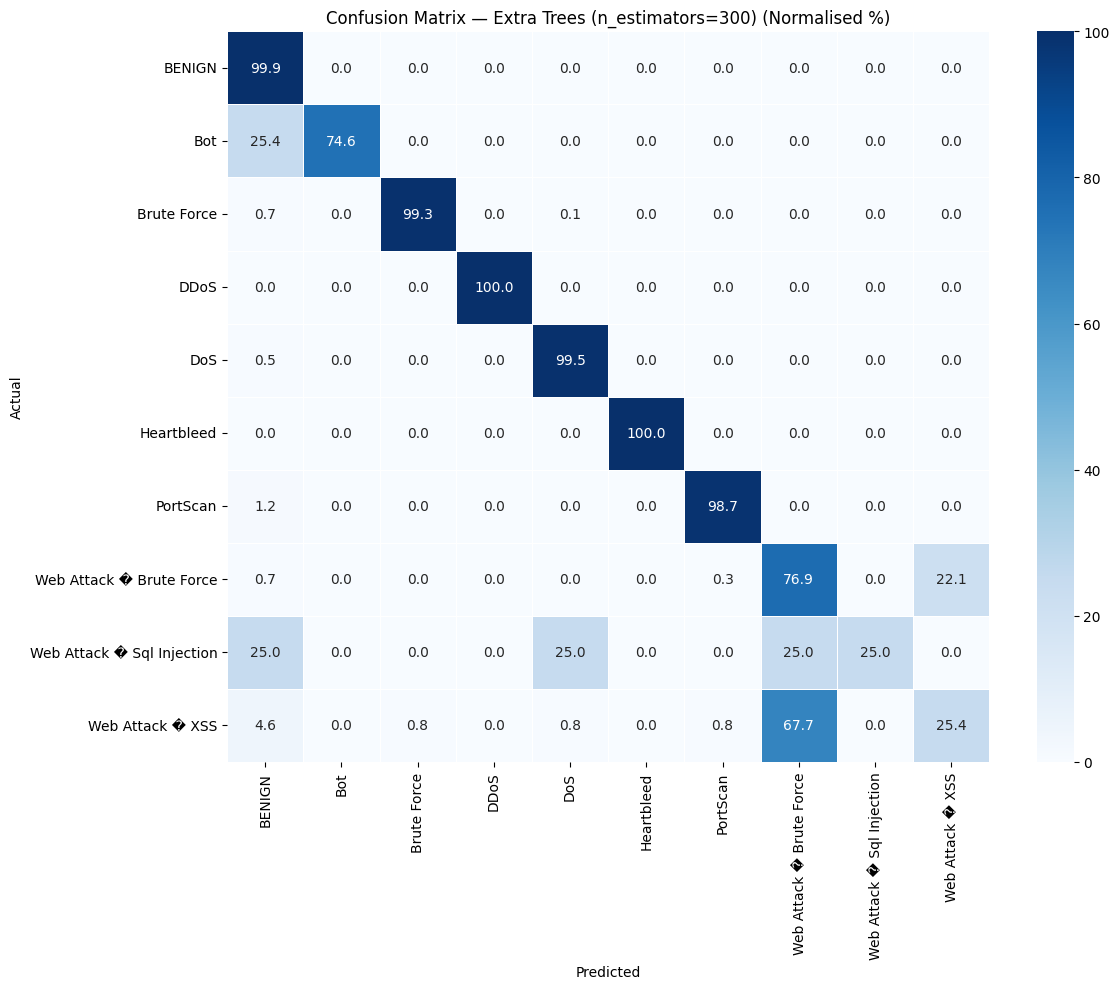

In [5]:
# --- STEP 4: Confusion Matrix ---
print("\n" + "=" * 70)
print("STEP 4: Confusion Matrix")
print("=" * 70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=et_model.classes_.tolist(),
    model_name="Extra Trees (n_estimators=300)",
    normalize=True,
    figsize=(12, 10),
)


STEP 5: Feature Importance (Top 20)
               Feature  Importance
        PSH Flag Count    0.048336
     Packet Length Std    0.048267
Bwd Packet Length Mean    0.045838
 Bwd Packet Length Std    0.045239
  min_seg_size_forward    0.039697
             Idle Mean    0.039317
 Bwd Packet Length Max    0.038884
              Idle Min    0.036129
    Packet Length Mean    0.035471
Packet Length Variance    0.035263
          Flow IAT Max    0.033870
   Average Packet Size    0.032941
              Idle Max    0.032616
           Fwd IAT Std    0.032214
      Destination Port    0.031831
           Fwd IAT Max    0.031093
 Bwd Packet Length Min    0.027074
Init_Win_bytes_forward    0.025367
     Total Fwd Packets    0.021452
     Max Packet Length    0.020734


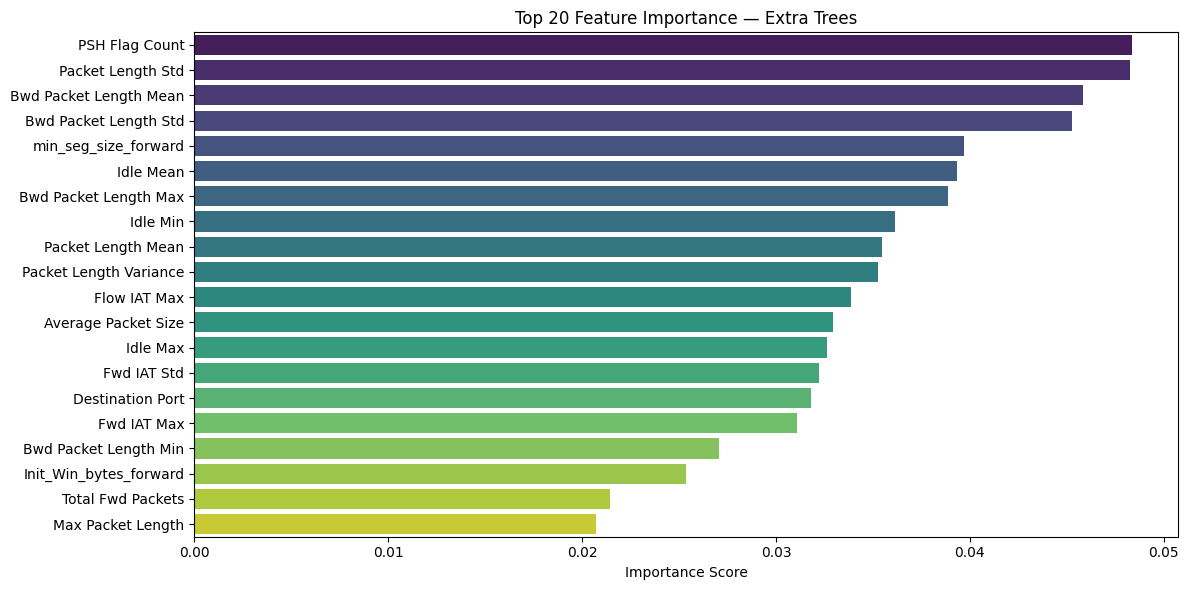

In [6]:
# --- STEP 5: Feature Importance ---
print("\n" + "=" * 70)
print("STEP 5: Feature Importance (Top 20)")
print("=" * 70)

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": et_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_imp.head(20),
    x="Importance", y="Feature",
    hue="Feature", legend=False,
    palette="viridis",
)
plt.title("Top 20 Feature Importance — Extra Trees")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [7]:
# --- STEP 6: Summary ---
print("\n" + "=" * 70)
print("STEP 6: Summary")
print("=" * 70)

comparison_df = compare_models([et_results])
print("\nPerformance Metrics:")
print(comparison_df.to_string(index=False))

print(f"\nTraining time  : {train_time:.2f}s")
print(f"Test set size  : {len(y_test):,}")
print(f"Estimators     : 300")
print(f"Features       : {X_train.shape[1]}")
print(f"Classes        : {len(et_model.classes_)}")


STEP 6: Summary

Performance Metrics:
                         Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Extra Trees (n_estimators=300)    0.9978                0.9978             0.8369             0.9978          0.7993         0.9978       0.813       0.9927 0.9927               0.999           0.9963

Training time  : 280.66s
Test set size  : 504,153
Estimators     : 300
Features       : 52
Classes        : 10
